In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# FitzHugh-Nagumo Model

The **FitzHugh-Nagumo (FHN) model** is a two-variable reduction of the Hodgkin-Huxley equations that captures neuronal **excitability** with a fast voltage variable $V$ and a slow recovery variable $w$:

$$\dot V = -\alpha V^3 + \beta V^2 + \gamma V - w + I,\qquad \dot w = \tfrac{1}{\tau}(V - \delta - \epsilon w).$$

Below a threshold the system returns to rest; a sufficiently strong input triggers a large excursion (a spike) before recovering. It is a canonical Type-II excitable system and a building block for whole-brain models.

**Reference:** FitzHugh (1961), *Impulses and physiological states in theoretical models of nerve membrane*, Biophysical Journal 1(6):445-466.

## Build the model

In [2]:
node = brainmass.FitzHughNagumoStep(in_size=1, tau=20. * u.ms)
node

FitzHughNagumoStep(
  in_size=(1,),
  out_size=(1,),
  alpha=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(3., dtype=float32)
  ),
  beta=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(4., dtype=float32)
  ),
  gamma=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(-1.5, dtype=float32)
  ),
  delta=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0., dtype=float32)
  ),
  epsilon=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.5, dtype=float32)
  ),
  tau=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(20., "ms")
  ),
  init_V=Uniform(low=0, high=0.05),
  init_w=Uniform(low=0, high=0.05),
  method=exp_euler
)

## Run a simulation

With the default parameters and a steady drive the node settles onto a relaxation limit cycle (repetitive spiking).

In [3]:
sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(400. * u.ms, inputs=lambda i, t: 1.0,
              monitors=['V', 'w'], transient=50. * u.ms)
res['V'].shape

(3500, 1)

## Visualize

The phase portrait shows the fast-slow limit cycle around the cubic `V`-nullcline.

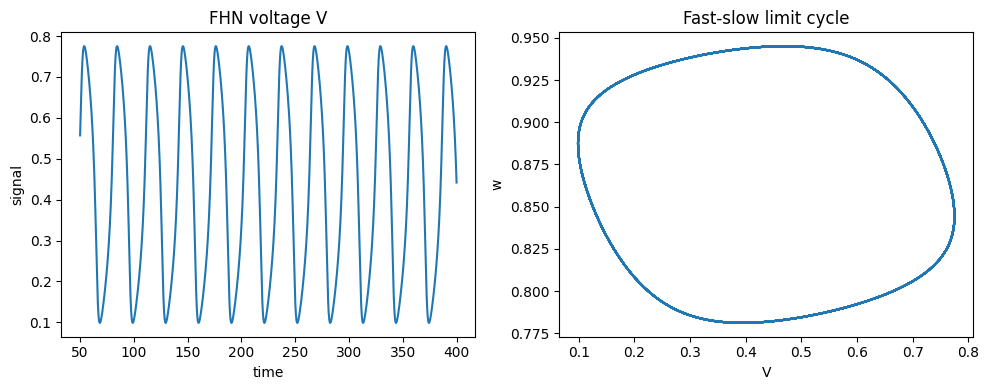

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
brainmass.viz.plot_timeseries(res['V'], ts=res['ts'], ax=axes[0])
axes[0].set_title('FHN voltage V')
brainmass.viz.plot_phase_portrait(res['V'], res['w'], ax=axes[1])
axes[1].set_xlabel('V'); axes[1].set_ylabel('w')
axes[1].set_title('Fast-slow limit cycle')
plt.tight_layout()
plt.show()

## Try it: vary the input drive `I`

The constant drive sets the regime. Weak drive leaves the node excitable (silent at rest); strong drive sustains repetitive spiking.

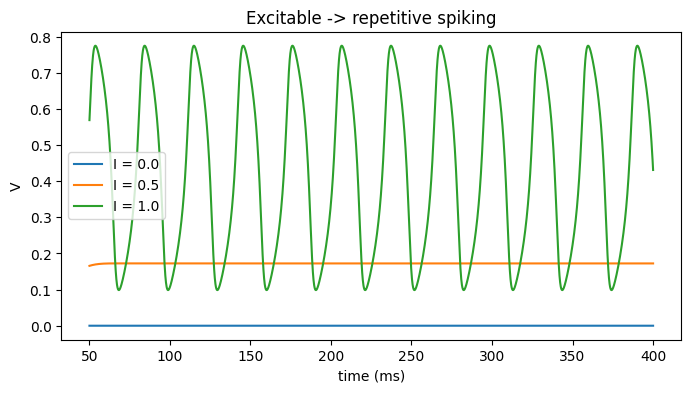

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for drive in [0.0, 0.5, 1.0]:
    m = brainmass.FitzHughNagumoStep(in_size=1, tau=20. * u.ms)
    r = brainmass.Simulator(m, dt=0.1 * u.ms).run(
        400. * u.ms, inputs=lambda i, t, d=drive: d,
        monitors=['V'], transient=50. * u.ms)
    ax.plot(u.get_magnitude(r['ts']), u.get_magnitude(r['V'])[:, 0], label=f'I = {drive}')
ax.set_xlabel('time (ms)'); ax.set_ylabel('V'); ax.legend()
ax.set_title('Excitable -> repetitive spiking')
plt.show()